# Plot IICRsim and IICRinf and get RMSE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl
import seaborn as sns



# ============================================================
## Theme
# ============================================================


In [5]:
def set_paper_theme():
    sns.set_theme(
        style="white",
        context="paper",
        rc={
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
            "font.size": 12,
            "axes.labelsize": 15,
            "axes.titlesize": 15,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 10,
            "legend.title_fontsize": 10,

            "axes.edgecolor": "#333333",
            "axes.linewidth": 0.8,
            "axes.facecolor": "white",
            "figure.facecolor": "white",

            "xtick.color": "#333333",
            "ytick.color": "#333333",
            "axes.labelcolor": "#222222",
            "text.color": "#222222",

            "legend.frameon": True,
            "legend.framealpha": 0.9,
            "legend.edgecolor": "#CCCCCC",

            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )


set_paper_theme()


# ============================================================
## Functions
# ============================================================


In [6]:

def rmse_log(iicr_sim, iicr_inf):
    """RMSE first, then log10(RMSE)."""
    iicr_sim = np.asarray(iicr_sim, dtype=float)
    iicr_inf = np.asarray(iicr_inf, dtype=float)

    ok = np.isfinite(iicr_sim) & np.isfinite(iicr_inf)

    rmse = np.sqrt(np.mean((iicr_sim[ok] - iicr_inf[ok]) ** 2))
    log_rmse = np.log10(rmse)

    return rmse, log_rmse



In [7]:

def read_iicr_file(file, labels, inference_col="PSMC_Inference", method="PSMC"):
    file = Path(file)

    df = pd.read_csv(file, sep="\t", dtype=str)
    df.columns = df.columns.str.replace("#", "", regex=False)

    df["row_id"] = df.index

    df["Time"] = df["Time"].str.split()
    df["IICR"] = df["IICR"].str.split()
    df[inference_col] = df[inference_col].str.split()

    df = df.explode(["Time", "IICR", inference_col], ignore_index=True)

    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["IICRsim"] = pd.to_numeric(df["IICR"], errors="coerce")
    df["IICRinf"] = pd.to_numeric(df[inference_col], errors="coerce")

    df["IICRsim"] = (
        df.groupby("row_id")["IICRsim"]
        .transform(lambda x: x.interpolate().ffill().bfill())
    )

    df["IICRinf"] = (
        df.groupby("row_id")["IICRinf"]
        .transform(lambda x: x.interpolate().ffill().bfill())
    )

    df["file"] = file.name
    df["label"] = labels[file.name]
    df["method"] = method

    return df[["file", "label", "method", "Time", "IICRsim", "IICRinf"]]




# ============================================================
## Vector PSMC
# ============================================================


In [8]:

directory = Path("/Users/alba/files/2026/structred_smc_IICR/vector_psmc")

files = [
    directory / "gyarados_StSi_s100_p4_25_2_4_6_psmc.log.out",
    directory / "gyarados_StSi_s100_p2_2_25_2_4_6_psmc.log.out",
    directory / "gyarados_StSi_s100_p1_1_1_1_25_2_4_6_psmc.log.out",
    directory / "gyarados_StSi_s100_p24_1_15_2_4_6_psmc.log.out",
]

labels = {
    "gyarados_StSi_s100_p4_25_2_4_6_psmc.log.out": "4+25*2+4+6 (default)",
    "gyarados_StSi_s100_p2_2_25_2_4_6_psmc.log.out": "2+2+25*2+4+6",
    "gyarados_StSi_s100_p1_1_1_1_25_2_4_6_psmc.log.out": "1+1+1+1+25*2+4+6",
    "gyarados_StSi_s100_p24_1_15_2_4_6_psmc.log.out": "24*1+15*2+4+6",
}

vector_order = [
    "4+25*2+4+6 (default)",
    "2+2+25*2+4+6",
    "1+1+1+1+25*2+4+6",
    "24*1+15*2+4+6",
]



### Read files



In [9]:


dat = pd.concat(
    [
        read_iicr_file(
            file=f,
            labels=labels,
            inference_col="PSMC_Inference",
            method="PSMC"
        )
        for f in files
    ],
    ignore_index=True
)

dat = dat[dat["Time"] <= 1e6].copy()


### Plot IICRsim + PSMC curves


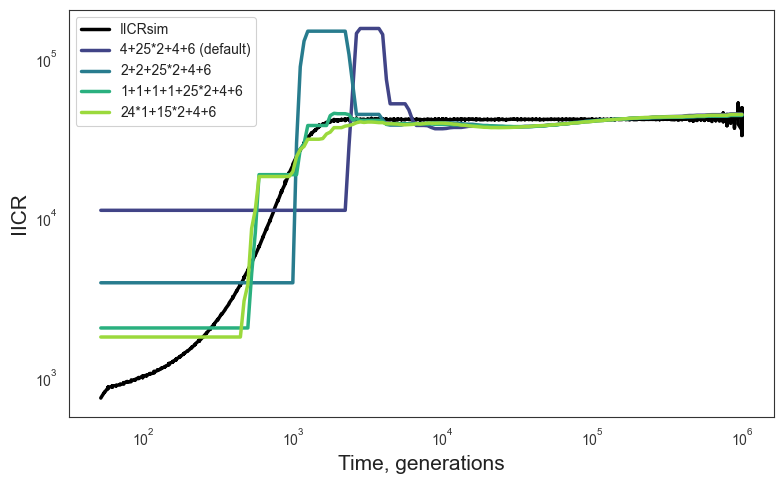

In [10]:
color_iicrsim = "#000000"
# Plot IICRsim + PSMC curves
plt.figure(figsize=(8, 5))


colors = sns.color_palette("viridis", as_cmap=True)(np.linspace(0.20, 0.85, len(vector_order)))

sim = (
    dat[["Time", "IICRsim"]]
    .dropna()
    .drop_duplicates()
    .sort_values("Time")
)

plt.plot(sim["Time"], sim["IICRsim"], color=color_iicrsim, lw=2.5, label="IICRsim")

for label, color in zip(vector_order, colors):
    sub = dat[dat["label"] == label]
    plt.plot(
        sub["Time"],
        sub["IICRinf"],
        lw=2.5,
        color=color,
        label=label
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time, generations")
plt.ylabel("IICR")
plt.legend()
plt.tight_layout()
plt.savefig(directory / "gyarados_PSMC_vectors_IICR.png", dpi=600)
plt.savefig(directory / "gyarados_PSMC_vectors_IICR.pdf", dpi=600)
plt.savefig(directory / "gyarados_PSMC_vectors_IICR.svg", dpi=600)
plt.show()



### RMSE table


In [11]:


rows = []

for label in vector_order:
    sub = dat[dat["label"] == label]

    rmse, log_rmse = rmse_log(sub["IICRsim"], sub["IICRinf"])

    rows.append({
        "label": label,
        "RMSE": rmse,
        "log10_RMSE": log_rmse
    })

rmse_df = pd.DataFrame(rows)
print(rmse_df)

rmse_df.to_csv(directory / "gyarados_PSMC_vectors_RMSE.csv", index=False)


                  label          RMSE  log10_RMSE
0  4+25*2+4+6 (default)  25853.869220    4.412526
1          2+2+25*2+4+6  30197.986360    4.479978
2      1+1+1+1+25*2+4+6   3051.143179    3.484463
3         24*1+15*2+4+6   3098.001432    3.491082


=====================================================
## Ditto: panmictic scenarios matching the exact same IICR as structured scenarios
====================================================

In [12]:
directory = Path("/Users/alba/files/2026/structred_smc_IICR/ditto_curves")

psmc_files = [
    directory / "gyarados_Free_s100_p4_25_2_4_6_psmc.log.out",
    directory / "gyarados_StSi_s100_p4_25_2_4_6_psmc.log.out",
]

smcpp_files = [
    directory / "gyarados_Free_smcpp.log.out",
    directory / "gyarados_StSi_smcpp.log.out",
]

labels = {
    "gyarados_Free_s100_p4_25_2_4_6_psmc.log.out": "PSMC Panmictic",
    "gyarados_StSi_s100_p4_25_2_4_6_psmc.log.out": "PSMC Structured",
    "gyarados_Free_smcpp.log.out": "SMC++ Panmictic",
    "gyarados_StSi_smcpp.log.out": "SMC++ Structured",
}

case_order = ["Panmictic", "Structured"]

### PSMC

In [13]:
dat_psmc = pd.concat(
    [
        read_iicr_file(
            file=f,
            labels=labels,
            inference_col="PSMC_Inference",
            method="PSMC"
        )
        for f in psmc_files
    ],
    ignore_index=True
)

dat_psmc = dat_psmc[dat_psmc["Time"] <= 1e6].copy()

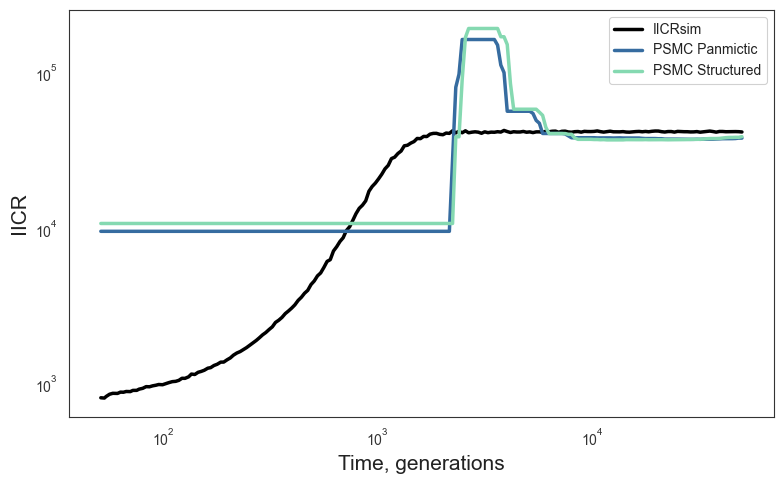

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

color_iicrsim = "#000000"
colors = sns.color_palette("mako", as_cmap=True)(
    np.linspace(0.45, 0.85, len(psmc_files))
)

# IICRsim from one file only
sim = (
    dat_psmc[dat_psmc["file"] == psmc_files[0].name][["Time", "IICRsim"]]
    .dropna()
    .sort_values("Time")
)

ax.plot(
    sim["Time"],
    sim["IICRsim"],
    color=color_iicrsim,
    lw=2.5,
    label="IICRsim"
)

for f, color in zip(psmc_files, colors):
    sub = dat_psmc[dat_psmc["file"] == f.name]

    ax.plot(
        sub["Time"],
        sub["IICRinf"],
        lw=2.5,
        color=color,
        label=labels[f.name]
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time, generations")
ax.set_ylabel("IICR")
ax.grid(False)
ax.legend()

fig.tight_layout()
fig.savefig(directory / "PSMC_Free_vs_StSi_IICR.png", dpi=600)
fig.savefig(directory / "PSMC_Free_vs_StSi_IICR.pdf", dpi=600)
fig.savefig(directory / "PSMC_Free_vs_StSi_IICR.svg", dpi=600)
plt.show()


### SMC++

In [15]:
dat_smcpp = pd.concat(
    [
        read_iicr_file(
            file=f,
            labels=labels,
            inference_col="SMCpp_Inference",
            method="SMC++"
        )
        for f in smcpp_files
    ],
    ignore_index=True
)

dat_smcpp = dat_smcpp[dat_smcpp["Time"] <= 1e6].copy()

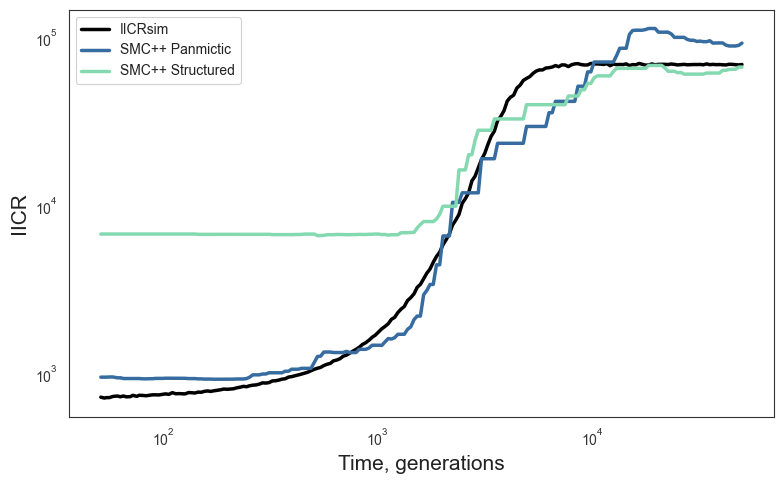

In [16]:
# Plot SMC++ curves

fig, ax = plt.subplots(figsize=(8, 5))

color_iicrsim = "#000000"
colors = sns.color_palette("mako", as_cmap=True)(
    np.linspace(0.45, 0.85, len(smcpp_files))
)

# IICRsim from one file only
sim = (
    dat_smcpp[dat_smcpp["file"] == smcpp_files[0].name][["Time", "IICRsim"]]
    .dropna()
    .sort_values("Time")
)

ax.plot(
    sim["Time"],
    sim["IICRsim"],
    color=color_iicrsim,
    lw=2.5,
    label="IICRsim"
)

for f, color in zip(smcpp_files, colors):
    sub = dat_smcpp[dat_smcpp["file"] == f.name]

    ax.plot(
        sub["Time"],
        sub["IICRinf"],
        lw=2.5,
        color=color,
        label=labels[f.name]
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time, generations")
ax.set_ylabel("IICR")
ax.grid(False)
ax.legend()

fig.tight_layout()
fig.savefig(directory / "SMCPP_Free_vs_StSi_IICR.png", dpi=600)
fig.savefig(directory / "SMCPP_Free_vs_StSi_IICR.pdf", dpi=600)
fig.savefig(directory / "SMCPP_Free_vs_StSi_IICR.svg", dpi=600)
plt.show()

Found 10 non-ditto files
Found 10 ditto files


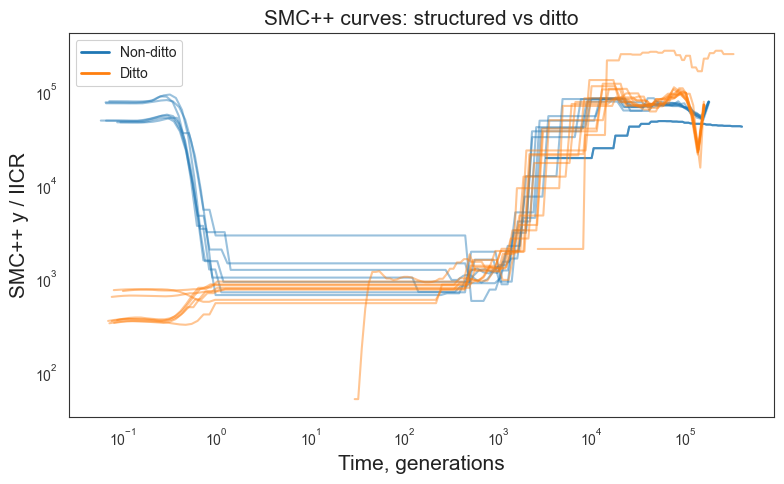

In [19]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# folder containing the CSV files
directory = Path("/Users/alba/files/2026/structred_smc_IICR/ditto_curves")

# restrict to this simulation
pattern = (
    "StSI_50I_N-50x1400_sam-49x0-1x20_m_-5.1374_size-5x100000000_mu_1.0E-08_gr_0_no_events*.csv"
)

files = sorted(directory.glob(pattern))

# split files
ditto_files = [f for f in files if "ditto" in f.name]
non_ditto_files = [f for f in files if "ditto" not in f.name]

print(f"Found {len(non_ditto_files)} non-ditto files")
print(f"Found {len(ditto_files)} ditto files")

def rep_number(path):
    """
    Extract the final individual index:
    ..._ind_G_1_10_start_0.csv -> 10
    ..._ind_G_1_3_start_0.csv  -> 3
    """
    m = re.search(r"_ind_G_1_(\d+)_start", path.name)
    return int(m.group(1)) if m else 9999

non_ditto_files = sorted(non_ditto_files, key=rep_number)
ditto_files = sorted(ditto_files, key=rep_number)

def read_curve(path):
    df = pd.read_csv(path)

    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")

    df = df.dropna(subset=["x", "y"])
    df = df[df["x"] > 0].copy()

    return df

plt.figure(figsize=(8, 5))

# non-ditto curves
for f in non_ditto_files:
    df = read_curve(f)
    plt.plot(
        df["x"],
        df["y"],
        color="tab:blue",
        alpha=0.45,
        lw=1.5
    )

# ditto curves
for f in ditto_files:
    df = read_curve(f)
    plt.plot(
        df["x"],
        df["y"],
        color="tab:orange",
        alpha=0.45,
        lw=1.5
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Time, generations")
plt.ylabel("SMC++ y / IICR")
plt.title("SMC++ curves: structured vs ditto")

legend_elements = [
    Line2D([0], [0], color="tab:blue", lw=2, label="Non-ditto"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Ditto"),
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [20]:
df

,label,x,y,plot_type,plot_num
1,G_1,0.100378,749.417958,path,0
2,G_1,0.115958,761.964469,path,0
3,G_1,0.133956,771.129628,path,0
4,G_1,0.154748,775.484919,path,0
5,G_1,0.178767,775.472668,path,0
...,...,...,...,...,...
96,G_1,90062.870456,95554.723236,path,0
97,G_1,104041.828572,85355.984353,path,0
98,G_1,120190.507339,55775.006592,path,0
99,G_1,138845.676327,24267.486687,path,0
